# Court Keypoint Detection Demo
Bare-bones YOLO keypoint detection on a video — no project classes.

In [1]:
import cv2
from ultralytics import YOLO

MODEL_PATH   = "models/court_keypoint_detector.pt"
INPUT_VIDEO  = "input_videos/video_2.mp4"
OUTPUT_VIDEO = "output_videos/court_keypoint_demo.mp4"

model = YOLO(MODEL_PATH)

In [2]:
cap = cv2.VideoCapture(INPUT_VIDEO)
fps    = cap.get(cv2.CAP_PROP_FPS) or 24.0
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    OUTPUT_VIDEO,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, conf=0.5, verbose=False)
    result  = results[0]

    if result.keypoints is not None:
        kps = result.keypoints.xy.tolist()  # list of detections, each a list of [x, y]
        for detection in kps:
            for idx, (x, y) in enumerate(detection):
                if x == 0 and y == 0:
                    continue  # keypoint not detected
                cx, cy = int(x), int(y)
                cv2.circle(frame, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(
                    frame,
                    str(idx),
                    (cx + 6, cy - 6),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.45,
                    (0, 255, 0),
                    1,
                )

    out.write(frame)

cap.release()
out.release()
print(f"Saved → {OUTPUT_VIDEO}")

Saved → output_videos/court_keypoint_demo.mp4


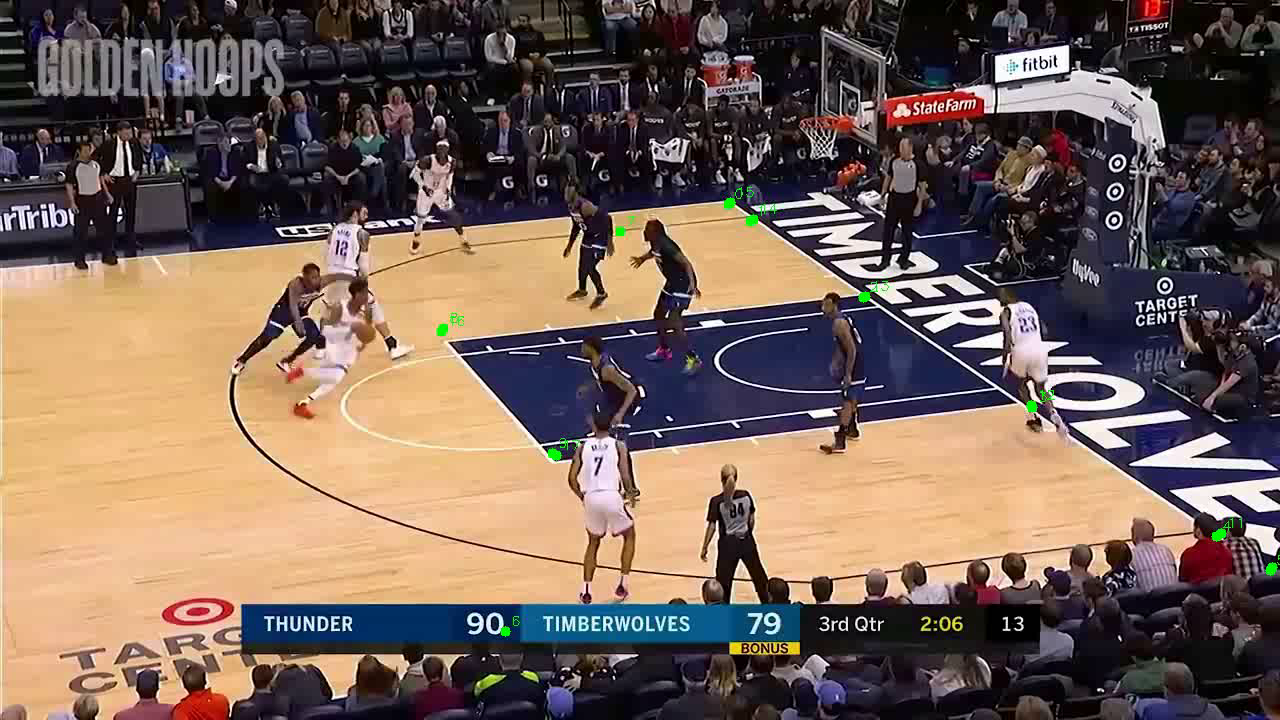

In [3]:
# Preview first annotated frame inline
from IPython.display import display
from PIL import Image

cap2 = cv2.VideoCapture(OUTPUT_VIDEO)
ret, preview_frame = cap2.read()
cap2.release()

if ret:
    display(Image.fromarray(cv2.cvtColor(preview_frame, cv2.COLOR_BGR2RGB)))